In [1]:
import re
import pandas as pd
import os
import nltk

local_nltk_data = r"D:\NLTK"
if local_nltk_data not in nltk.data.path:
    nltk.data.path.append(local_nltk_data)

from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

df = pd.read_csv("6-4-customer_review_keywords_by_Twitter_RoBERTa_v21.csv")


In [2]:
# 安全检查
required_cols = {"label", "keyword", "count"}
missing_cols = required_cols - set(df.columns)
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# 统一列名
df = df.rename(columns={"keyword": "keyword_raw"})
df["keyword"] = df["keyword_raw"].fillna("").astype(str).str.strip()

# =========================================================
# 2) 语义规范化规则
# 重点：保持短语语义稳定，不人为制造情感词
# =========================================================
REPLACE_MAP = {
    r"\bluv\b": "love",
    r"\bgreat thing great\b": "great thing",
    r"\bgreat thing\b": "great thing",
    r"\bdoesn t work\b": "doesn't work",
    r"\bdoesn work\b": "doesn't work",
    r"\bdoesnt work\b": "doesn't work",
    r"\bstar didn\b": "star didn't",
    r"\bstar didn t\b": "star didn't",
    r"\blight weight\b": "lightweight",
    r"\blight-weight\b": "lightweight",
    r"\blarge head make\b": "large head",
    r"\bhandy love glasses\b": "love glasses",
    r"\bhandy love\b": "handy",
    r"\bgreat thing order\b": "great order",
    r"\bgreat order\b": "great order",
    r"\bphotos great value\b": "great photos value",
    r"\bshipping took longer\b": "shipping took longer",
    r"\bshipping took\b": "shipping took",
    r"\bfit perfect\b": "perfect fit",
    r"\bperfect fit\b": "perfect fit",
    r"\bquality vision sharp\b": "vision sharp quality",
    r"\bcomfortable lightweight\b": "comfortable lightweight",
    r"\bquality received\b": "quality received",
    r"\bframe feels cheap\b": "frame feels cheap",
    r"\bfeels cheap\b": "feels cheap",
    r"\bpoor quality\b": "poor quality",
    r"\bcheap plastic\b": "cheap plastic",
}

# 词典式同义词归一（可继续扩展）
SYNONYM_MAP = {
    "light weight": "lightweight",
    "light-weight": "lightweight",
    "fit perfect": "perfect fit",
    "quality vision sharp": "vision sharp quality",
    "great thing": "great",
    "great thing great": "great",
    "great order": "great order",
    "lenses clear frame": "clear frame",
    "glasses super helpful": "helpful glasses",
    "comfortable long wear": "uncomfortable long wear",
    "wear service friendly": "service friendly",
    "shipping glasses look": "shipping look",
    "photos great value": "great photos value",
    "large head make": "large head",
    "handy love": "handy",
    "happy quality vision": "happy quality vision",
    "best purchase 2025": "best purchase",
    "best action": "best action",
    "reading glasses": "reading glasses",
}

def clean_text(s: str) -> str:
    if pd.isna(s):
        return ""

    text = str(s).lower().strip()

    # 1. 正则修正
    for pat, repl in REPLACE_MAP.items():
        text = re.sub(pat, repl, text)

    # 2. 统一常见同义表达
    for old, new in SYNONYM_MAP.items():
        text = re.sub(rf"\\b{re.escape(old)}\\b", new, text)

    # 3. 只保留英文/数字/空格/撇号
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    # 4. 保守词形还原，防止过度压缩
    words = []
    for w in text.split():
        w = lemmatizer.lemmatize(w)
        if len(w) > 1:
            words.append(w)

    return " ".join(words)

# =========================================================
# 3) 清洗
# =========================================================
df["keyword_clean"] = df["keyword"].apply(clean_text)

# 去掉空值、过短、过于碎片的关键词
df = df[df["keyword_clean"].astype(str).str.len() > 2].copy()

# 去掉重复（按 label + keyword_clean）
df = df.drop_duplicates(subset=["label", "keyword_clean"]).copy()

# 进一步过滤明显无意义的短语：保留更像“产品/体验/问题”的内容
bad_patterns = [
    r"^a+$",
    r"^the$",
    r"^and$",
    r"^or$",
    r"^very$",
    r"^just$",
    r"^really$",
    r"^thing$",
    r"^stuff$",
]

df = df[~df["keyword_clean"].str.match("|".join(bad_patterns), na=False)].copy()

# 处理 count 列
df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(1).astype(int)

# 结果保存
df.to_csv(
    "6-4-1-customer_review_keywords_by_Twitter_RoBERTa_v21_cleaned.csv",
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# 4) 为 BERTopic 做聚类准备：按关键词汇总并保留权重
# =========================================================
# 因为每条关键词本身已经是一个“表达”，保留它们即可
# 这里把 count 作为重复权重，用于提高高频短语的权重
keyword_summary = (
    df.groupby("keyword_clean", as_index=False)
      .agg(count=("count", "sum"),
           label=("label", lambda s: s.mode().iloc[0] if len(s) else "unknown"))
)

# 生成 BERTopic 输入文档：高频关键词重复出现
documents = []
for _, row in keyword_summary.iterrows():
    kw = row["keyword_clean"]
    cnt = int(row["count"])
    # 让高频关键词在聚类中更重要，但不要太夸张
    repeats = max(1, min(cnt, 20))
    documents.extend([kw] * repeats)

# 先打印一下清洗后的样本
print("Cleaned sample:")
print(keyword_summary.head(20).to_string(index=False))


Cleaned sample:
             keyword_clean  count    label
       2025 look beautiful     29 positive
adventure capturing device     29 positive
                 app glass     32 negative
            arrived broken      6 negative
  audio microphone quality     27 positive
               bad quality     10 negative
              battery life     30 positive
               best action     24 positive
        best purchase 2025     37 positive
                 broke day      4 negative
               broke frame      4 negative
                broke week      5 negative
    build quality received     41 positive
               buy coating      5 negative
                  buy lens      5 negative
              buy shipping      4 negative
              came scratch     23 negative
 came scratch prescription      4 negative
            camera quality     49 positive
    capability mic speaker     30 positive


In [ ]:

# =========================================================
# 5) BERTopic 聚类
# =========================================================
# 如果还没装依赖，运行：
import torch
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

# 1) 本地模型路径
# 例如你已经下载好了模型到这个目录
model_path = r"D:\huggingface_models\sentence-transformers-all-MiniLM-L6-v2"

# 2) 选择设备
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


d:\miniconda_envs\junliangvenv_nlp1\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:13: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm, trange


Using device: cuda


In [4]:
embedding_model = SentenceTransformer(model_path, device=device)

# 2) 只保留唯一关键词，不重复扩展 count
docs_unique = keyword_summary["keyword_clean"].tolist()

# 3) 先分成 positive / negative 两组
docs_positive = (
    keyword_summary[keyword_summary["label"] == "positive"]["keyword_clean"]
    .dropna()
    .astype(str)
    .tolist()
)

docs_negative = (
    keyword_summary[keyword_summary["label"] == "negative"]["keyword_clean"]
    .dropna()
    .astype(str)
    .tolist()
)

print(f"Positive docs: {len(docs_positive)}")
print(f"Negative docs: {len(docs_negative)}")

# =========================================================
# 5.1) Positive 聚类
# =========================================================
positive_model = BERTopic(
    embedding_model=embedding_model,
    language="english",
    min_topic_size=5,
    nr_topics="auto",
    verbose=True
)

positive_topics, positive_probs = positive_model.fit_transform(docs_positive)

positive_topic_map = pd.DataFrame({
    "keyword_clean": docs_positive,
    "topic_positive": positive_topics
})

positive_topic_info = positive_model.get_topic_info()
print("\n=== Positive Topic Info ===")
print(positive_topic_info[["Topic", "Count"]].head(20))

for topic_id in positive_topic_info["Topic"].head(10):
    if topic_id == -1:
        continue
    print(f"\nPositive Topic {topic_id}:")
    print(positive_model.get_topic(topic_id)[:10])

# =========================================================
# 5.2) Negative 聚类
# =========================================================
negative_model = BERTopic(
    embedding_model=embedding_model,
    language="english",
    min_topic_size=5,
    nr_topics="auto",
    verbose=True
)

negative_topics, negative_probs = negative_model.fit_transform(docs_negative)

negative_topic_map = pd.DataFrame({
    "keyword_clean": docs_negative,
    "topic_negative": negative_topics
})

negative_topic_info = negative_model.get_topic_info()
print("\n=== Negative Topic Info ===")
print(negative_topic_info[["Topic", "Count"]].head(20))

for topic_id in negative_topic_info["Topic"].head(10):
    if topic_id == -1:
        continue
    print(f"\nNegative Topic {topic_id}:")
    print(negative_model.get_topic(topic_id)[:10])

# =========================================================
# 6) 合并回原始 summary
# =========================================================
final_topic_df = keyword_summary.merge(
    positive_topic_map,
    on="keyword_clean",
    how="left"
).merge(
    negative_topic_map,
    on="keyword_clean",
    how="left"
)

# 7) 统一主题字段，便于后续分析
final_topic_df["topic"] = final_topic_df["topic_positive"].combine_first(final_topic_df["topic_negative"])

# 8) 保存最终结果
output_file = "6-4-1-customer_review_keywords_by_Twitter_RoBERTa_v21_topic_result_v2.csv"
final_topic_df.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\nFinal topic result saved to:", output_file)
print(final_topic_df.head(20).to_string(index=False))

2026-09-18 16:44:30,266 - BERTopic - Embedding - Transforming documents to embeddings.


Positive docs: 97
Negative docs: 100


Batches: 100%|██████████| 4/4 [00:00<00:00, 20.60it/s]
2026-09-18 16:44:30,460 - BERTopic - Embedding - Completed ✓
2026-09-18 16:44:30,460 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-18 16:44:40,398 - BERTopic - Dimensionality - Completed ✓
2026-09-18 16:44:40,398 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-18 16:44:40,398 - BERTopic - Cluster - Completed ✓
2026-09-18 16:44:40,398 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-18 16:44:40,410 - BERTopic - Representation - Completed ✓
2026-09-18 16:44:40,411 - BERTopic - Topic reduction - Reducing number of topics
2026-09-18 16:44:40,415 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-18 16:44:40,421 - BERTopic - Representation - Completed ✓
2026-09-18 16:44:40,422 - BERTopic - Topic reduction - Reduced number of topics from 5 to 5
2026-09-18 16:44:40,436 - BERTopic - Embedding - Transfo


=== Positive Topic Info ===
   Topic  Count
0     -1      7
1      0     39
2      1     26
3      2     13
4      3     12

Positive Topic 0:
[('great', np.float64(0.19670907818639002)), ('quality', np.float64(0.11573932653343146)), ('product', np.float64(0.11399774922051274)), ('excellent', np.float64(0.11399774922051274)), ('build', np.float64(0.09444044480187387)), ('received', np.float64(0.09444044480187387)), ('husband', np.float64(0.09444044480187387)), ('thing', np.float64(0.08549831191538455)), ('love', np.float64(0.07869513337060072)), ('best', np.float64(0.07153057388596001))]

Positive Topic 1:
[('vision', np.float64(0.17107637689261027)), ('quality', np.float64(0.15096433895664974)), ('video', np.float64(0.1231831888720094)), ('phone', np.float64(0.1231831888720094)), ('clear', np.float64(0.11151953728093637)), ('sharp', np.float64(0.11151953728093637)), ('display', np.float64(0.09330074854690437)), ('camera', np.float64(0.09330074854690437)), ('prescription', np.float64(

Batches: 100%|██████████| 4/4 [00:00<00:00, 38.78it/s]
2026-09-18 16:44:40,543 - BERTopic - Embedding - Completed ✓
2026-09-18 16:44:40,543 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-18 16:44:40,616 - BERTopic - Dimensionality - Completed ✓
2026-09-18 16:44:40,616 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-18 16:44:40,616 - BERTopic - Cluster - Completed ✓
2026-09-18 16:44:40,616 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-18 16:44:40,616 - BERTopic - Representation - Completed ✓
2026-09-18 16:44:40,616 - BERTopic - Topic reduction - Reducing number of topics
2026-09-18 16:44:40,632 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-18 16:44:40,637 - BERTopic - Representation - Completed ✓
2026-09-18 16:44:40,637 - BERTopic - Topic reduction - Reduced number of topics from 5 to 5



=== Negative Topic Info ===
   Topic  Count
0     -1      2
1      0     67
2      1     13
3      2      9
4      3      9

Negative Topic 0:
[('cheap', np.float64(0.10589476036611775)), ('fit', np.float64(0.09109246676791545)), ('shipping', np.float64(0.09109246676791545)), ('quality', np.float64(0.08767233657863105)), ('trouble', np.float64(0.08325601698053757)), ('long', np.float64(0.07457980274354545)), ('comfortable', np.float64(0.07457980274354545)), ('took', np.float64(0.07457980274354545)), ('star', np.float64(0.07457980274354545)), ('wear', np.float64(0.07457980274354545))]

Negative Topic 1:
[('coating', np.float64(0.39030096769122113)), ('prescription', np.float64(0.39030096769122113)), ('scratch', np.float64(0.3122407741529769)), ('started', np.float64(0.28134107167600364)), ('peeling', np.float64(0.28134107167600364)), ('slightly', np.float64(0.28134107167600364)), ('disappointed', np.float64(0.1452354962882711)), ('came', np.float64(0.1452354962882711)), ('month', np.fl


=== 主题汇总表（按 label + topic_name） ===
   label                           topic_name  keyword_count  total_count
negative              general dissatisfaction             67          750
negative    lens coating / prescription issue             13          161
negative     lens scratch / replacement issue              9           84
negative             frame quality & breakage              9           80
negative                         unclassified              2           35
positive overall product quality&Satisfaction             39         1567
positive optical clarity & camera performance             26          905
positive                 comfort weight & fit             13          484
positive       smart AI glasses functionality             12          467
positive                         unclassified              7          243

=== 主题占比 ===
                          topic_name  total_count  share_pct
overall product quality&Satisfaction         1567  32.809883
optical clari

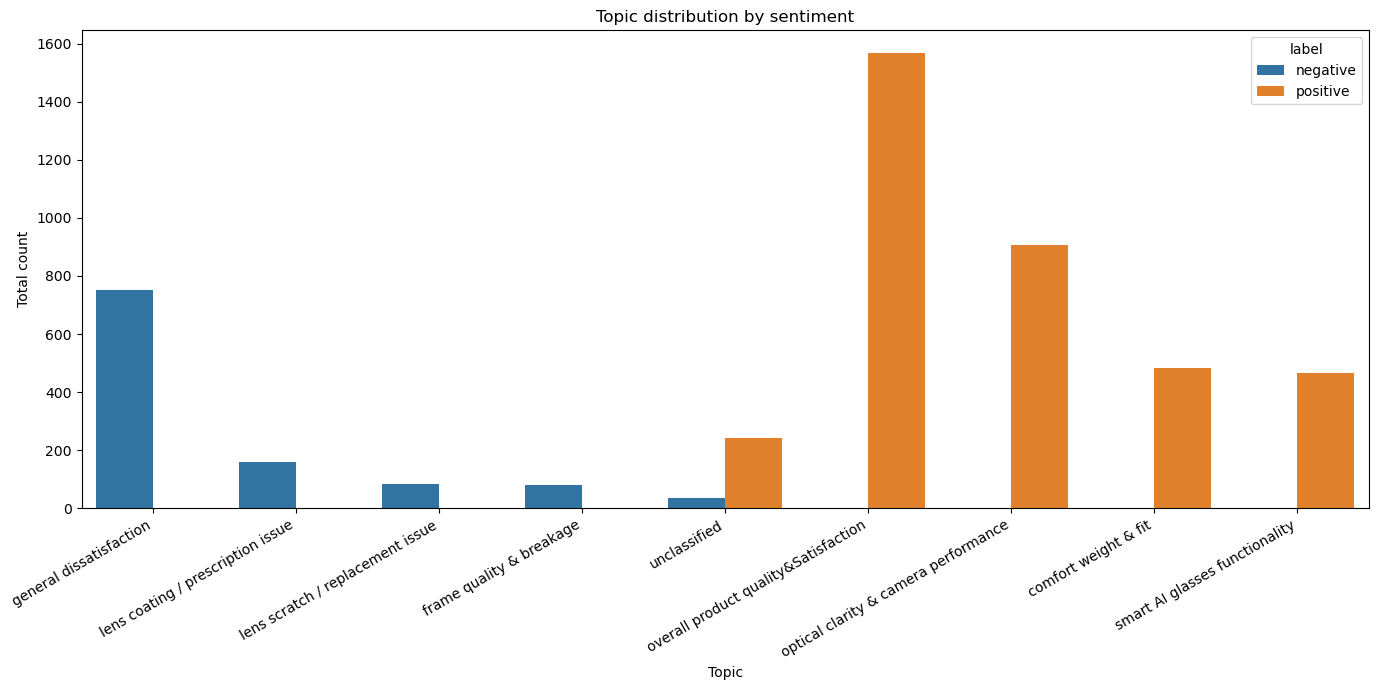


=== 每个主题下的关键词列表 ===

----- POSITIVE -----

[positive] comfort weight & fit
                     keyword_clean  count
                       perfect fit     60
                        large head     44
                   sure large feel     42
                 frame feel sturdy     42
           comfortable lightweight     39
              comfortable day wear     37
   lightweight definitely purchase     37
                    case bit bulky     35
comfortable lightweight definitely     32
                       lightweight     31
                  size peanut head     30
                   large feel snug     28

[positive] optical clarity & camera performance
                keyword_clean  count
             vision sharp fit     58
         vision sharp quality     54
               camera quality     49
             lens clear frame     48
         phone trying display     43
               quality vision     39
prescription accurate problem     39
                  display one    

In [ ]:
# =========================================================
# 主题命名 + 汇总统计 + 可视化
# =========================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 主题命名映射
POS_TOPIC_NAMES = {
    0: "overall product quality&Satisfaction",
    1: "optical clarity & camera performance",
    2: "comfort weight & fit",
    3: "smart AI glasses functionality",
    -1: "unclassified"
}

NEG_TOPIC_NAMES = {
    0: "general dissatisfaction",
    1: "lens coating / prescription issue",
    2: "frame quality & breakage",
    3: "lens scratch / replacement issue",
    -1: "unclassified"
}

def map_topic_name(row):
    label = row["label"]
    if label == "positive":
        topic_id = row["topic_positive"]
        return POS_TOPIC_NAMES.get(topic_id, "unclassified")
    elif label == "negative":
        topic_id = row["topic_negative"]
        return NEG_TOPIC_NAMES.get(topic_id, "unclassified")
    return "unknown"

# 2) 生成主题名称列
final_topic_df["topic_name"] = final_topic_df.apply(map_topic_name, axis=1)

# 3) 主题汇总：按 topic 汇总 count
topic_summary = (
    final_topic_df.groupby(["label", "topic_name"], as_index=False)
    .agg(
        keyword_count=("keyword_clean", "count"),
        total_count=("count", "sum")
    )
    .sort_values(["label", "total_count"], ascending=[True, False])
)
topic_summary.to_parquet(
    "6-4-1-customer_review_keywords_by_Twitter_RoBERTa_v21_topic_summary.parquet",
    index=False,
    engine="pyarrow"
)

# 4) 主题占比（总占比）
topic_share = (
    topic_summary.groupby("topic_name", as_index=False)
    .agg(total_count=("total_count", "sum"))
)

topic_share["share_pct"] = topic_share["total_count"] / topic_share["total_count"].sum() * 100
topic_share = topic_share.sort_values("total_count", ascending=False)

print("\n=== 主题汇总表（按 label + topic_name） ===")
print(topic_summary.to_string(index=False))

print("\n=== 主题占比 ===")
print(topic_share.to_string(index=False))

# 5) 主题可视化：正负主题对比
plt.figure(figsize=(14, 7))
sns.barplot(
    data=topic_summary,
    x="topic_name",
    y="total_count",
    hue="label"
)
plt.xticks(rotation=30, ha="right")
plt.title("Topic distribution by sentiment")
plt.ylabel("Total count")
plt.xlabel("Topic")
plt.tight_layout()
plt.show()

# 6) 每个主题下的关键词列表（按 count 降序）
print("\n=== 每个主题下的关键词列表 ===")
for label in ["positive", "negative"]:
    print(f"\n----- {label.upper()} -----")
    label_df = final_topic_df[final_topic_df["label"] == label].copy()
    for topic_name, group in label_df.groupby("topic_name"):
        print(f"\n[{label}] {topic_name}")
        top_keywords = (
            group.sort_values("count", ascending=False)[["keyword_clean", "count"]]
            .head(12)
            .reset_index(drop=True)
        )
        print(top_keywords.to_string(index=False))
    label_df.to_parquet(
        f"6-4-1-customer_review_keywords_by_Twitter_RoBERTa_v21_{label}_keywords.parquet",
        index=False,
        engine="pyarrow"
    )
